In [67]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt


In [64]:
df = pd.read_csv("data/EDA.csv")

df.head()


,WD EID,Emp Name,Answered,AHT,Month,Year,Dayofweek,Monthly_AHT,Dayofweek_AHT,Monthly_Answered,Dayofweek_Answered,Shift
0,102496670,Dieu Tien,60.0,452.0,5,2026,6,452.818182,473.666667,60.181818,57.666667,Day
1,102496670,Dieu Tien,60.0,451.0,5,2026,0,452.818182,476.500000,60.181818,57.500000,Day
2,102496670,Dieu Tien,70.0,414.0,5,2026,1,452.818182,411.500000,60.181818,67.500000,Day
3,102496670,Dieu Tien,70.0,406.0,5,2026,4,452.818182,451.000000,60.181818,63.500000,Day
4,102496670,Dieu Tien,55.0,412.0,5,2026,5,452.818182,441.000000,60.181818,56.000000,Day


In [65]:
#1. Univariate Analysis
#Number of handled tickets and AHT on average:
df[["Answered", "AHT"]].describe()



,Answered,AHT
count,952.000000,952.000000
mean,54.310924,456.045168
std,20.794118,202.896588
min,1.000000,148.000000
25%,44.000000,360.750000
50%,58.000000,411.000000
75%,69.000000,514.000000
max,109.000000,3359.000000


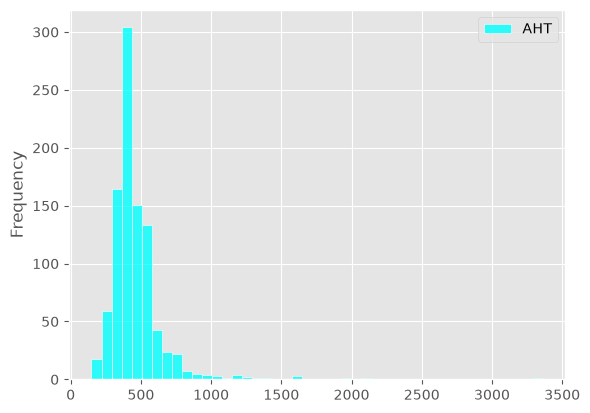

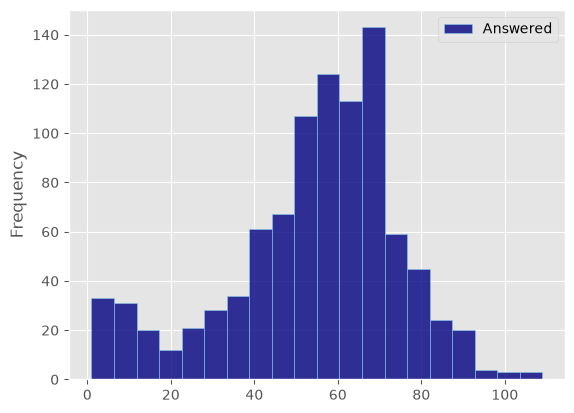

In [93]:
#Use histogram to explore the variance of AHT and Answered number

plt.style.use("ggplot")


hist_AHT = df[["AHT"]].plot.hist(bins = 45, alpha=0.8, color="cyan", edgecolor="white")
hist_Ans = df[["Answered"]].plot.hist(bins = 20, alpha=0.8, color="navy", edgecolor="skyblue")
plt.show()


According to output, we see that avg AHT in 3 months is 456.05 seconds with 54 cases handled. 
Min AHT and Answered are 1 case and 148 seconds respectively.
Max AHT and Answered are 109 cases and 3359 seconds respectively.


count	952.000000	952.000000
mean	54.310924	456.045168
std	20.794118	202.896588
min	1.000000	148.000000
25%	44.000000	360.750000
50%	58.000000	411.000000
75%	69.000000	514.000000
max	109.000000	3359.000000

Furthermore, as per historgrams, we observe that there's a plenty of variance of AHT and cases handled, the threshold that mostly shared is around 370-440 seconds while someone handles faster (below 300s) yet other ones strugling with complex cases resulting in negative AHT (> 1000 seconds). Answered cases seem to be relative as it also has a diverse variance, but in most of the time, everyone can handle 50 - 70 cases per day.



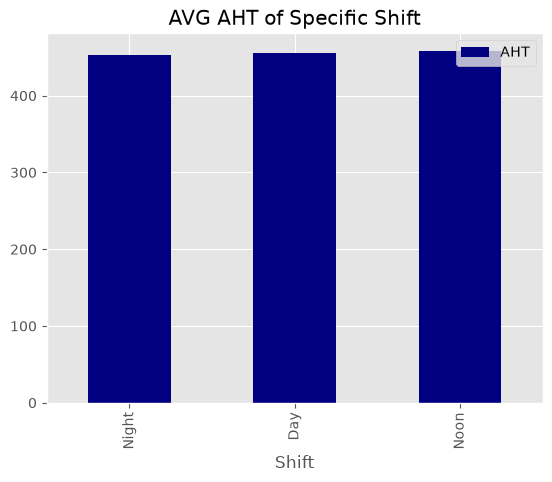

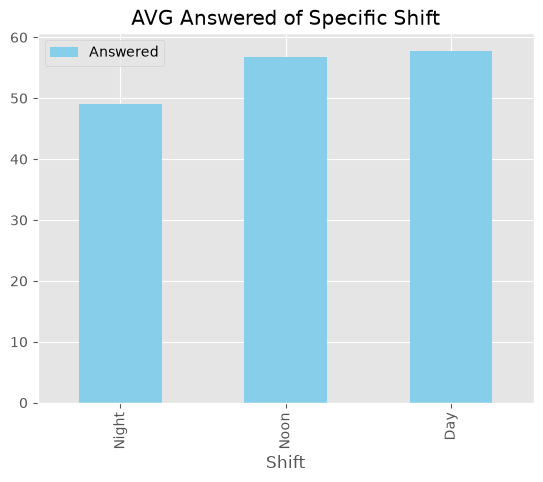

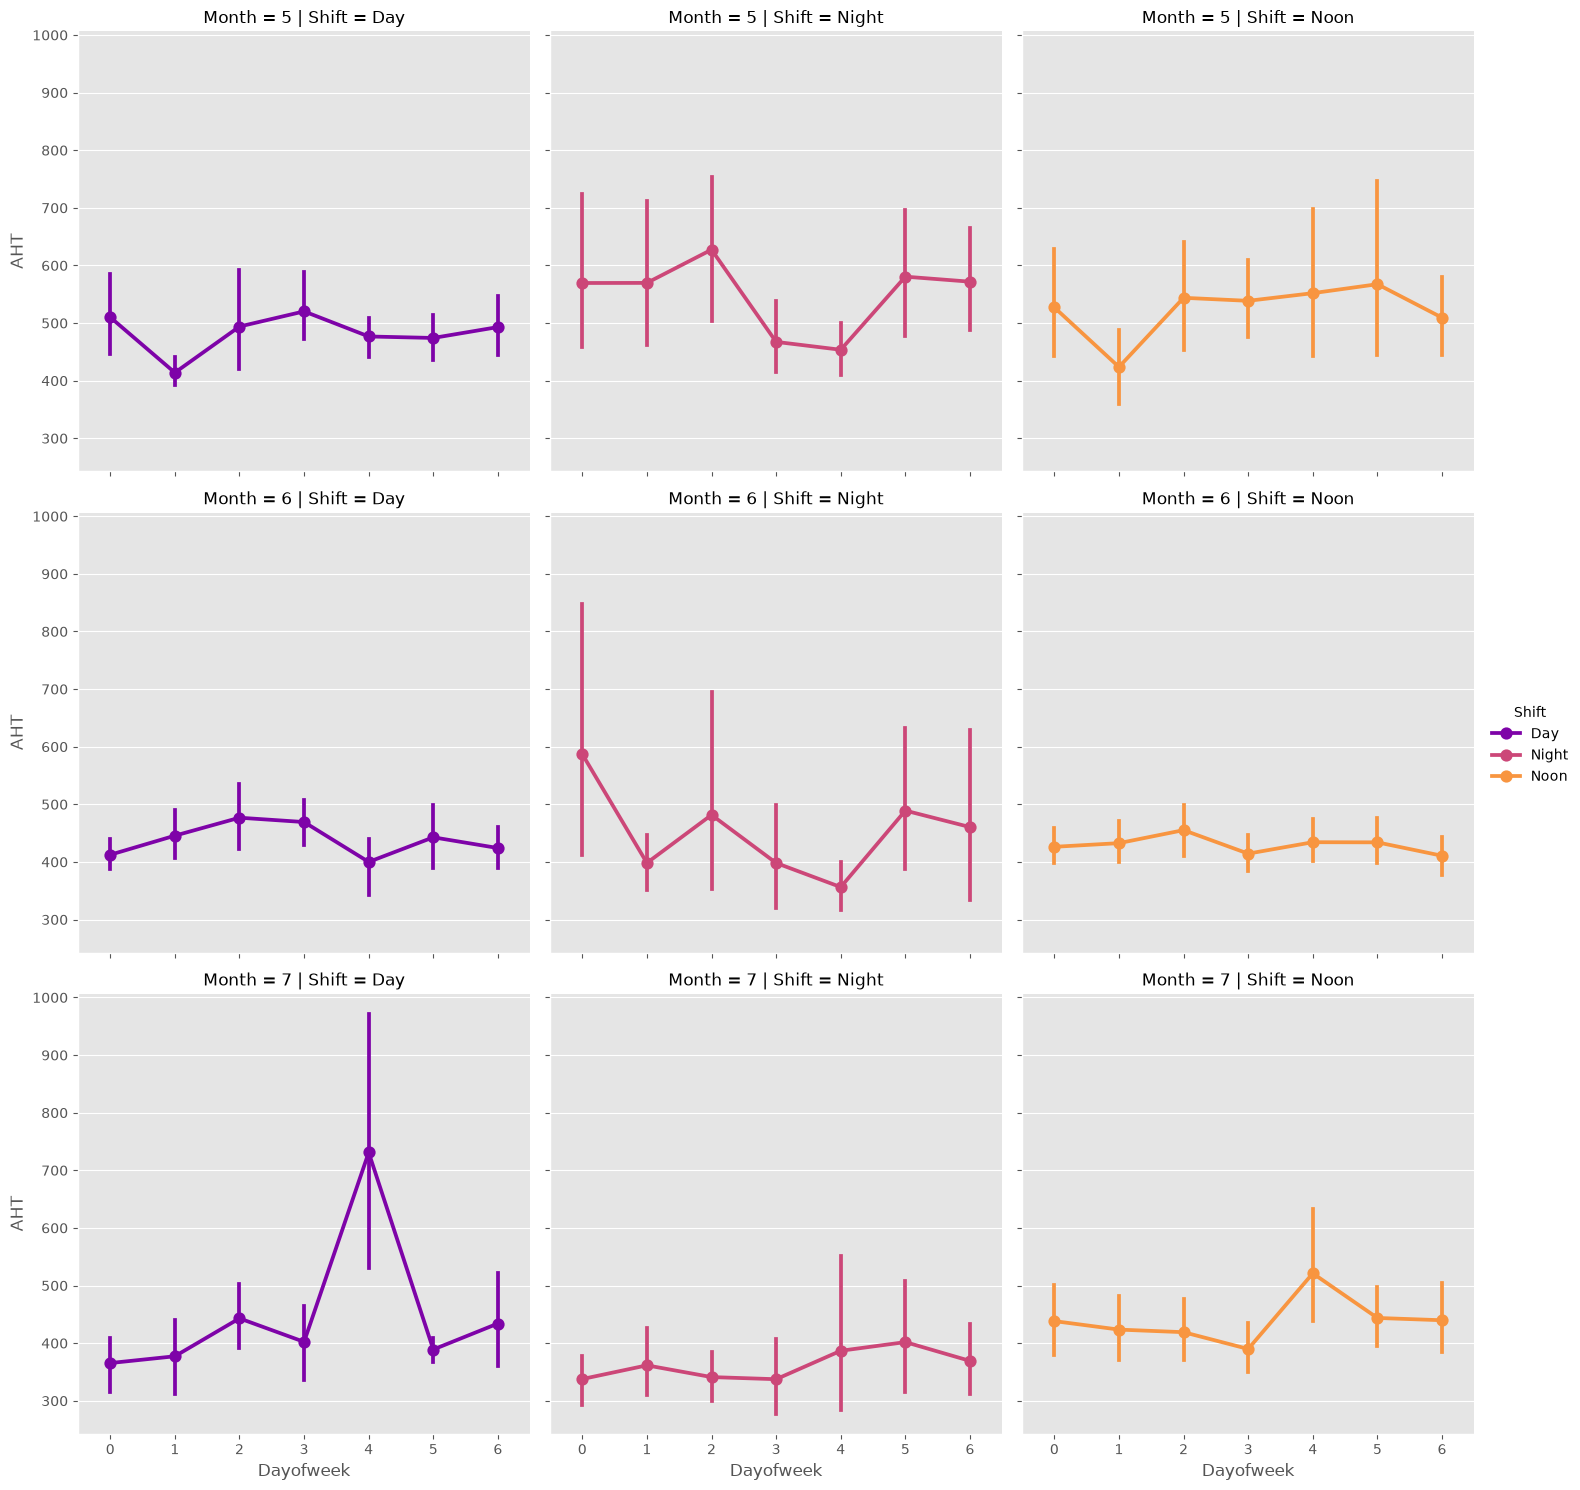

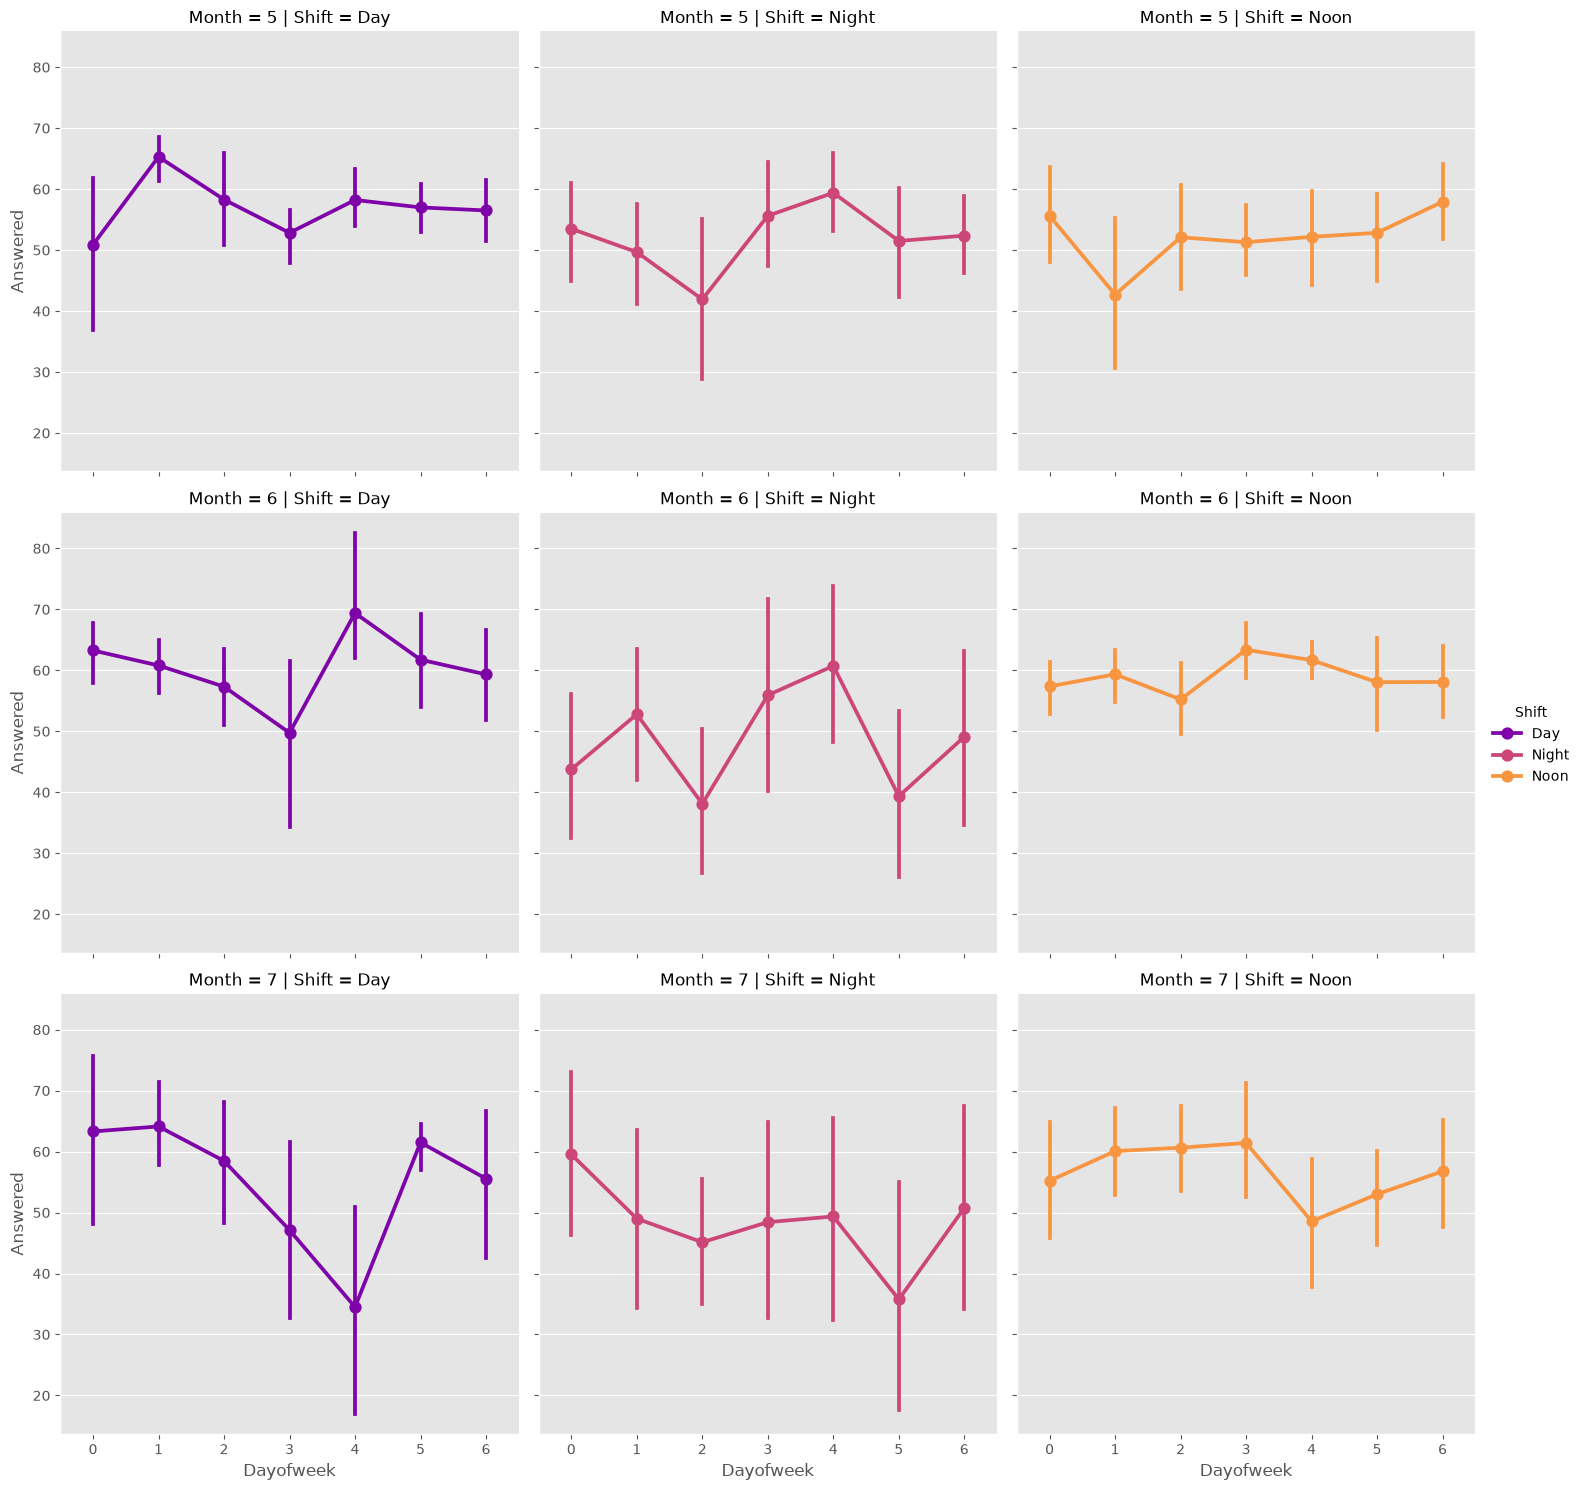

In [146]:
#2. Time Series Analysis

df.groupby("Shift")["AHT"].mean().reset_index().set_index("Shift").sort_values("AHT").plot.bar(color="Navy", title="AVG AHT of Specific Shift")

df.groupby("Shift")["Answered"].mean().reset_index().set_index("Shift").sort_values("Answered").plot.bar(color="Skyblue", title="AVG Answered of Specific Shift")

#AHT
sns.catplot(data = df, x = "Dayofweek", y = "AHT", 
               col = "Shift",
               row= "Month",
               hue="Shift",
               kind= "point",
               palette = "plasma"
)
#Answered
sns.catplot(data = df, x = "Dayofweek", y = "Answered", 
               col = "Shift",
               row= "Month",
               hue="Shift",
               kind= "point",
               palette = "plasma"
)

#Description: Week starts at 0 meaning Monday and ends at 6 meaning Sunday

In [ ]:
df_shift_insight = df.groupby("Shift").agg(
    avg_AHT=("AHT", "mean"),
    avg_Answered=("Answered", "mean")
).reset_index()

overall_mean_aht = df["AHT"].mean()
overall_mean_answered = df["Answered"].mean()


df_shift_insight["diff_AHT_vs_overall"] = df_shift_insight["avg_AHT"] - overall_mean_aht
df_shift_insight["diff_Answered_vs_overall"] = df_shift_insight["avg_Answered"] - overall_mean_answered

df_shift_insight

#Description:
#diff_AHT_vs_overall < 0 is better
#diff_Answered_vs_overall > 0 is better



,Shift,avg_AHT,avg_Answered,diff_AHT_vs_overall,diff_Answered_vs_overall
0,Day,455.300000,57.794737,-0.745168,3.483812
1,Night,453.131902,49.085890,-2.913266,-5.225035
2,Noon,458.548165,56.699541,2.502997,2.388617


In [176]:
df_AHT_Ans_trend = df.groupby(["Month", "Dayofweek"]).agg(
    avg_AHT_weekday = ("AHT", "mean"),
    avg_Answered_weekday = ("Answered", "mean")
).reset_index()
Month_AHT_Ans = df.groupby("Month").agg(
    avg_AHT_month = ("AHT", "mean"),
    avg_Answered_month = ("Answered", "mean")
)

reports = pd.merge(df_AHT_Ans_trend, Month_AHT_Ans, how="inner", left_on="Month", right_on="Month")

reports = reports.assign(
    AHT_diff = (((reports.avg_AHT_weekday - reports.avg_AHT_month)/reports.avg_AHT_month)*100).map("{:.2f}%".format),
    Answered_diff = (((reports.avg_Answered_weekday - reports.avg_Answered_month)/reports.avg_AHT_weekday)*100).map("{:.2f}%".format),
)

reports


,Month,Dayofweek,avg_AHT_weekday,avg_Answered_weekday,avg_AHT_month,avg_Answered_month,AHT_diff,Answered_diff
0,5,0,536.783784,53.783784,524.247191,53.554307,2.39%,0.04%
1,5,1,471.028571,51.542857,524.247191,53.554307,-10.15%,-0.43%
2,5,2,566.413793,49.379310,524.247191,53.554307,8.04%,-0.74%
3,5,3,516.709677,52.709677,524.247191,53.554307,-1.44%,-0.16%
4,5,4,505.861111,55.694444,524.247191,53.554307,-3.51%,0.42%
5,5,5,548.100000,53.475000,524.247191,53.554307,4.55%,-0.01%
6,5,6,526.237288,55.847458,524.247191,53.554307,0.38%,0.44%
7,6,0,472.180723,54.337349,440.768116,55.657005,7.13%,-0.28%
8,6,1,424.215190,57.556962,440.768116,55.657005,-3.76%,0.45%
9,6,2,467.206897,49.948276,440.768116,55.657005,6.00%,-1.22%


Part 2 actually brings on many interesting insights covering critial parts of our dataset.

To be in the first place, Day, Noon and Night shifts average handling time are almost the same, skeptically, Noon shift has the highest AHT but it does not look like a big deal here. The same instance shared with handled cases number diff.
However, by somehow, Night shift which has lowest AHT is also the one with lowest handled cases.

